<a href="https://colab.research.google.com/github/bidallei/MIAAD-UACJ/blob/main/07_HernandezAlvaro_EjercicioAplicacionRedesGAN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Ejercicio de aplicación de redes GAN**

* Asignatura: Redes Neuronales Profundas
* Profesor: Dr. José David Díaz Román
* Alumno: **Álvaro Hernández Jarquín**
* Matrícula: 263150
* 5 de abril de 2026




## **Parte 1 – Reproducción del modelo base (MNIST)**

1. Ejecutar el código base proporcionado (GAN con MNIST).
2. Guardar y analizar:
   * Las imágenes generadas cada 10 épocas (función generate_images()).
   * La curva de pérdidas de generador y discriminador.
3. Incluir en el reporte:
   * Explicación de cómo se calcula y utiliza la pérdida en cada modelo.
   * Comentarios sobre el comportamiento observado:
      * ¿Qué tendencia muestran las pérdidas?
      * ¿Las imágenes mejoran con las épocas?


In [1]:
# Importar las librerías necesarias
import tensorflow as tf
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# 🔧 Configurar GPU para asignar memoria de forma dinámica
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            # Esto evita que TF reserve toda la memoria de la GPU de golpe
            tf.config.experimental.set_memory_growth(gpu, True)
        print("✅ Memoria de GPU configurada para crecimiento dinámico.")
    except RuntimeError as e:
        print("❌ Error al configurar memoria de GPU:", e)

✅ Memoria de GPU configurada para crecimiento dinámico.


In [3]:
# Cargar MNIST
(x_train, _), (_, _) = tf.keras.datasets.mnist.load_data()
x_train = (x_train - 127.5) / 127.5   #normalización
x_train = np.expand_dims(x_train, axis=-1)
BUFFER_SIZE = 60000
BATCH_SIZE = 128

dataset = tf.data.Dataset.from_tensor_slices(x_train).shuffle(BUFFER_SIZE).batch(BATCH_SIZE)

print(x_train.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
(60000, 28, 28, 1)


In [4]:
def build_generator():
    model = tf.keras.Sequential([
        layers.Input(shape=(100,)),
        layers.Dense(7*7*256, use_bias=False),
        layers.BatchNormalization(),
        layers.LeakyReLU(),
        layers.Reshape((7, 7, 256)),
        layers.Conv2DTranspose(128, (5,5), strides=(1,1), padding='same', use_bias=False),
        layers.BatchNormalization(),
        layers.LeakyReLU(),
        layers.Conv2DTranspose(64, (5,5), strides=(2,2), padding='same', use_bias=False),
        layers.BatchNormalization(),
        layers.LeakyReLU(),
        layers.Conv2DTranspose(1, (5,5), strides=(2,2), padding='same', use_bias=False, activation='tanh')
    ])
    return model

def build_discriminator():
    model = tf.keras.Sequential([
        layers.Input(shape=(28, 28, 1)),
        layers.Conv2D(64, (5,5), strides=(2,2), padding='same'),
        layers.LeakyReLU(),
        layers.Dropout(0.3),
        layers.Conv2D(128, (5,5), strides=(2,2), padding='same'),
        layers.LeakyReLU(),
        layers.Dropout(0.3),
        layers.Flatten(),
        layers.Dense(1, activation='sigmoid')
    ])
    return model

In [5]:
generator = build_generator()
discriminator = build_discriminator()

cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=False)

def generator_loss(fake_output):
    return cross_entropy(tf.ones_like(fake_output), fake_output)

def discriminator_loss(real_output, fake_output):
    real_loss = cross_entropy(tf.ones_like(real_output), real_output)
    fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)
    return real_loss + fake_loss

g_optimizer = tf.keras.optimizers.Adam(1e-4)
d_optimizer = tf.keras.optimizers.Adam(1e-4)

Epoch 1/50 | G Loss: 0.7628 | D Loss: 1.1893


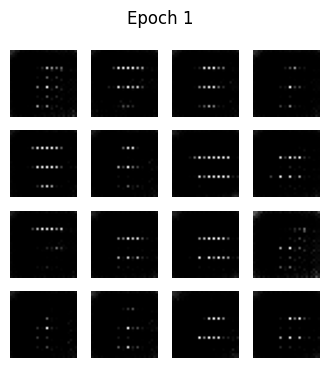

Epoch 2/50 | G Loss: 0.9136 | D Loss: 1.2018
Epoch 3/50 | G Loss: 0.8928 | D Loss: 1.2339
Epoch 4/50 | G Loss: 0.8961 | D Loss: 1.2666
Epoch 5/50 | G Loss: 0.9117 | D Loss: 1.2364
Epoch 6/50 | G Loss: 0.9257 | D Loss: 1.2081
Epoch 7/50 | G Loss: 1.0459 | D Loss: 1.1425
Epoch 8/50 | G Loss: 1.1103 | D Loss: 1.0880
Epoch 9/50 | G Loss: 1.1179 | D Loss: 1.0949
Epoch 10/50 | G Loss: 1.1714 | D Loss: 1.0688


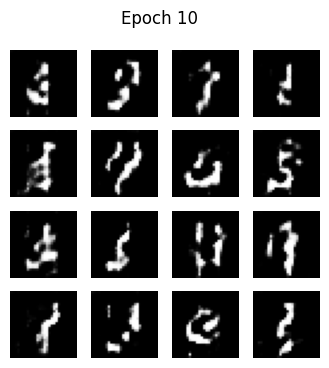

Epoch 11/50 | G Loss: 1.2875 | D Loss: 1.0064
Epoch 12/50 | G Loss: 1.2404 | D Loss: 1.0329
Epoch 13/50 | G Loss: 1.2342 | D Loss: 1.0592
Epoch 14/50 | G Loss: 1.1676 | D Loss: 1.0971
Epoch 15/50 | G Loss: 1.0790 | D Loss: 1.1578
Epoch 16/50 | G Loss: 1.1431 | D Loss: 1.1347
Epoch 17/50 | G Loss: 1.1086 | D Loss: 1.1441
Epoch 18/50 | G Loss: 1.0047 | D Loss: 1.1952
Epoch 19/50 | G Loss: 0.9774 | D Loss: 1.2286
Epoch 20/50 | G Loss: 0.9860 | D Loss: 1.2292


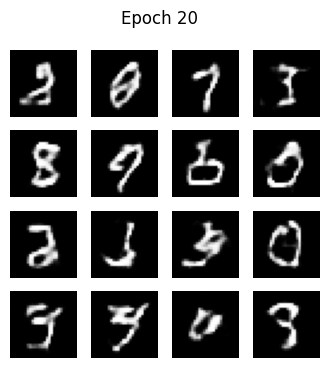

Epoch 21/50 | G Loss: 0.9367 | D Loss: 1.2494
Epoch 22/50 | G Loss: 0.9164 | D Loss: 1.2484
Epoch 23/50 | G Loss: 0.9293 | D Loss: 1.2476
Epoch 24/50 | G Loss: 0.9371 | D Loss: 1.2418
Epoch 25/50 | G Loss: 0.9354 | D Loss: 1.2433
Epoch 26/50 | G Loss: 0.9104 | D Loss: 1.2554
Epoch 27/50 | G Loss: 0.9143 | D Loss: 1.2476
Epoch 28/50 | G Loss: 0.9000 | D Loss: 1.2558
Epoch 29/50 | G Loss: 0.9153 | D Loss: 1.2472
Epoch 30/50 | G Loss: 0.9258 | D Loss: 1.2484


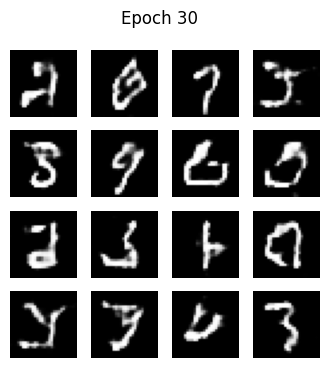

Epoch 31/50 | G Loss: 0.9017 | D Loss: 1.2477
Epoch 32/50 | G Loss: 0.9105 | D Loss: 1.2510
Epoch 33/50 | G Loss: 0.8889 | D Loss: 1.2600
Epoch 34/50 | G Loss: 0.9424 | D Loss: 1.2499
Epoch 35/50 | G Loss: 0.9071 | D Loss: 1.2559
Epoch 36/50 | G Loss: 0.9059 | D Loss: 1.2509
Epoch 37/50 | G Loss: 0.9150 | D Loss: 1.2469
Epoch 38/50 | G Loss: 0.9225 | D Loss: 1.2523
Epoch 39/50 | G Loss: 0.8965 | D Loss: 1.2680
Epoch 40/50 | G Loss: 0.8811 | D Loss: 1.2595


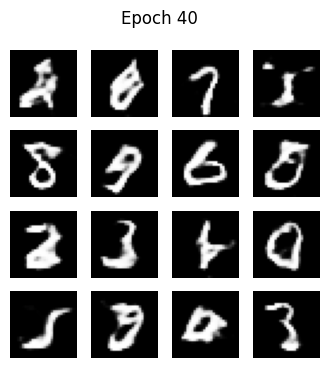

Epoch 41/50 | G Loss: 0.9171 | D Loss: 1.2491
Epoch 42/50 | G Loss: 0.9163 | D Loss: 1.2449
Epoch 43/50 | G Loss: 0.9192 | D Loss: 1.2460
Epoch 44/50 | G Loss: 0.9093 | D Loss: 1.2509
Epoch 45/50 | G Loss: 0.8865 | D Loss: 1.2609
Epoch 46/50 | G Loss: 0.9224 | D Loss: 1.2487
Epoch 47/50 | G Loss: 0.9180 | D Loss: 1.2553
Epoch 48/50 | G Loss: 0.8982 | D Loss: 1.2552
Epoch 49/50 | G Loss: 0.8895 | D Loss: 1.2636
Epoch 50/50 | G Loss: 0.9135 | D Loss: 1.2562


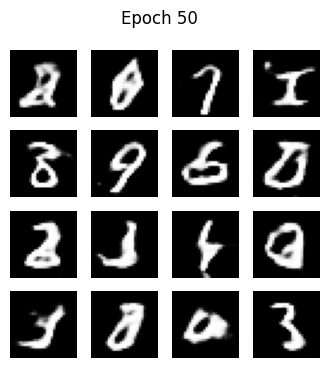

In [6]:
EPOCHS = 50
noise_dim = 100
num_examples = 16
seed = tf.random.normal([num_examples, noise_dim])  # genera un lote de 16 señales ruidosas de 100 datos

g_losses = []
d_losses = []
# Ciclo de entrenamiento pata un lote de datos
@tf.function
def train_step(images):  # función que permite ajustar los pesos del generador y discr usando un lote de datos
    noise = tf.random.normal([BATCH_SIZE, noise_dim])  # genera un lote de señales de ruido (ruido de 100 muestras)
    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:   #permite generar una iteración de entrenamiento con un lote
        generated = generator(noise, training=True)  # envía un lote de ruido al generador y obtiene la salida del generador
        real_output = discriminator(images, training=True)  # envía al discriminador un lote de imagenes verdaderas
        fake_output = discriminator(generated, training=True)  # envía un lote de imágenes generadas por el generador (falsas)
        g_loss = generator_loss(fake_output)  # calcula la pérdida para ajuste del generador
        d_loss = discriminator_loss(real_output, fake_output)  # calcula la pérdida para ajuste del discriminador

    gradients_gen = gen_tape.gradient(g_loss, generator.trainable_variables)  # calcula los gradientes de los parámetros del generador
    gradients_disc = disc_tape.gradient(d_loss, discriminator.trainable_variables)  # calcula los gradientes de los params del discriminador

    g_optimizer.apply_gradients(zip(gradients_gen, generator.trainable_variables)) # el optimizador actualiza los pesos del generador
    d_optimizer.apply_gradients(zip(gradients_disc, discriminator.trainable_variables)) # el optimizador actualiza los pesos del discriminador

    return g_loss, d_loss

def train(dataset, epochs):  # entrenamiento general
    for epoch in range(epochs):
        g_loss_epoch = []
        d_loss_epoch = []

        for image_batch in dataset: # Genera un lote de imagenes verdaderas con sus etiquetas
            g_loss, d_loss = train_step(image_batch)  #envía las imágenes verdaderas y sus etiquetas a la función train_step
            g_loss_epoch.append(g_loss)
            d_loss_epoch.append(d_loss)

        # Guardar el promedio de pérdidas por época
        g_losses.append(np.mean(g_loss_epoch))
        d_losses.append(np.mean(d_loss_epoch))

        print(f"Epoch {epoch+1}/{epochs} | "
              f"G Loss: {g_losses[-1]:.4f} | D Loss: {d_losses[-1]:.4f}")

        # Solo se generan imágenes en la primera época, y luego cada 10 épocas
        if (epoch + 1) % 10 == 0 or epoch == 0:
            generate_images(generator, epoch+1, seed)

def generate_images(model, epoch, test_input):  # pruega el generador entrenado en cada época con un lote de 16 señales ruidosas
    predictions = model(test_input, training=False) # el generador genera un lote de 16 imágenes a partir de ruido
    fig = plt.figure(figsize=(4,4))
    for i in range(predictions.shape[0]):  # se muestran las 16 imágenes generadas
        plt.subplot(4,4,i+1)
        plt.imshow((predictions[i, :, :, 0] + 1) / 2, cmap='gray')
        plt.axis('off')
    plt.suptitle(f"Epoch {epoch}")
    plt.show()

train(dataset, EPOCHS)

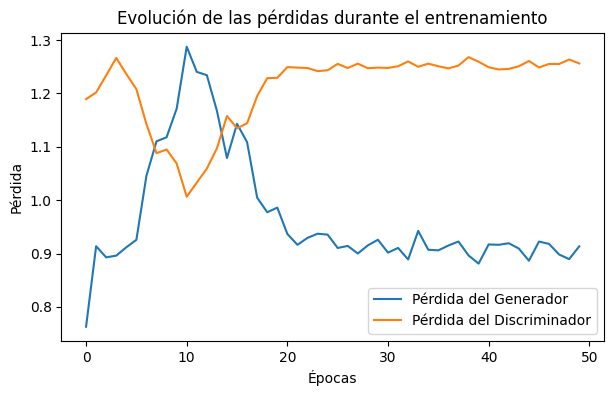

In [7]:
# Mostrar curva de pérdidas al final
plt.figure(figsize=(7, 4))
plt.plot(g_losses, label="Pérdida del Generador")
plt.plot(d_losses, label="Pérdida del Discriminador")
plt.xlabel("Épocas")
plt.ylabel("Pérdida")
plt.title("Evolución de las pérdidas durante el entrenamiento")
plt.legend()
plt.show()

## **Parte 2 – Experimento adicional**

**Base de datos Fashion-MNIST**

Usa la base tf.keras.datasets.fashion_mnist (con prendas de ropa). Esta base de datos tiene imágenes de las mismas dimensiones de la base de datos MNIST de números.

* Reentrenar la misma arquitectura.
* Observar si el modelo logra generar imágenes reconocibles (zapatillas, camisetas, etc.).
* Comentar si el discriminador aprende más lentamente o rápidamente respecto a MNIST.


In [9]:
# Cargar Fashion-MNIST
(x_train_fashion, _), (_, _) = tf.keras.datasets.fashion_mnist.load_data()
x_train_fashion = (x_train_fashion - 127.5) / 127.5   # normalización al rango [-1, 1]
x_train_fashion = np.expand_dims(x_train_fashion, axis=-1)

dataset_fashion = tf.data.Dataset.from_tensor_slices(x_train_fashion).shuffle(BUFFER_SIZE).batch(BATCH_SIZE)

print(f"Forma de los datos de Fashion-MNIST: {x_train_fashion.shape}")

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Forma de los datos de Fashion-MNIST: (60000, 28, 28, 1)


In [10]:
generator = build_generator()
discriminator = build_discriminator()

g_optimizer = tf.keras.optimizers.Adam(1e-4)
d_optimizer = tf.keras.optimizers.Adam(1e-4)

Epoch 1/50 | G Loss: 0.9313 | D Loss: 1.0911


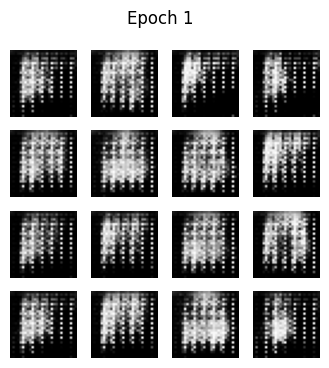

Epoch 2/50 | G Loss: 0.9355 | D Loss: 1.2512
Epoch 3/50 | G Loss: 0.8358 | D Loss: 1.2681
Epoch 4/50 | G Loss: 0.9746 | D Loss: 1.1883
Epoch 5/50 | G Loss: 0.8988 | D Loss: 1.2351
Epoch 6/50 | G Loss: 1.0274 | D Loss: 1.1421
Epoch 7/50 | G Loss: 1.1081 | D Loss: 1.0994
Epoch 8/50 | G Loss: 1.1689 | D Loss: 1.0339
Epoch 9/50 | G Loss: 1.2124 | D Loss: 0.9759
Epoch 10/50 | G Loss: 1.4167 | D Loss: 0.8514


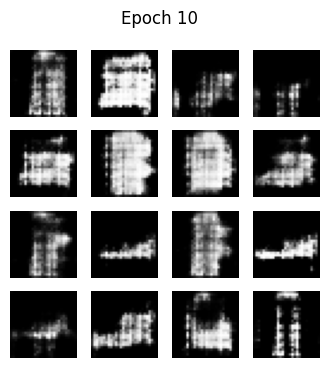

Epoch 11/50 | G Loss: 1.5282 | D Loss: 0.8432
Epoch 12/50 | G Loss: 1.6195 | D Loss: 0.8387
Epoch 13/50 | G Loss: 1.5563 | D Loss: 0.8391
Epoch 14/50 | G Loss: 1.6167 | D Loss: 0.8235
Epoch 15/50 | G Loss: 1.4822 | D Loss: 0.8883
Epoch 16/50 | G Loss: 1.5162 | D Loss: 0.8835
Epoch 17/50 | G Loss: 1.5433 | D Loss: 0.8364
Epoch 18/50 | G Loss: 1.5221 | D Loss: 0.8727
Epoch 19/50 | G Loss: 1.5765 | D Loss: 0.8230
Epoch 20/50 | G Loss: 1.5576 | D Loss: 0.8614


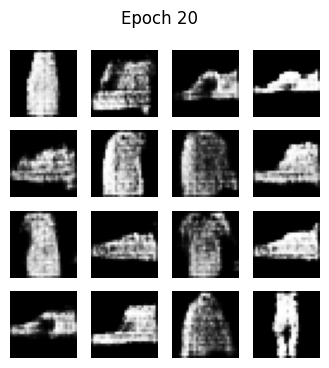

Epoch 21/50 | G Loss: 1.4435 | D Loss: 0.9378
Epoch 22/50 | G Loss: 1.3364 | D Loss: 0.9996
Epoch 23/50 | G Loss: 1.3807 | D Loss: 0.9615
Epoch 24/50 | G Loss: 1.4844 | D Loss: 0.8984
Epoch 25/50 | G Loss: 1.4920 | D Loss: 0.8942
Epoch 26/50 | G Loss: 1.4254 | D Loss: 0.9511
Epoch 27/50 | G Loss: 1.3620 | D Loss: 0.9733
Epoch 28/50 | G Loss: 1.3908 | D Loss: 0.9622
Epoch 29/50 | G Loss: 1.4008 | D Loss: 0.9393
Epoch 30/50 | G Loss: 1.3558 | D Loss: 0.9920


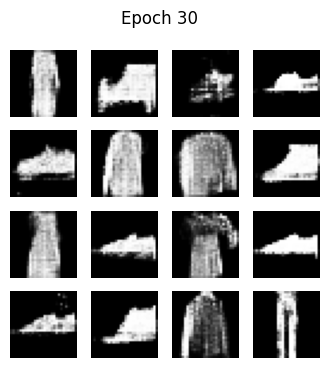

Epoch 31/50 | G Loss: 1.3247 | D Loss: 1.0127
Epoch 32/50 | G Loss: 1.2995 | D Loss: 1.0052
Epoch 33/50 | G Loss: 1.2684 | D Loss: 1.0219
Epoch 34/50 | G Loss: 1.2604 | D Loss: 1.0260
Epoch 35/50 | G Loss: 1.2774 | D Loss: 1.0310
Epoch 36/50 | G Loss: 1.2736 | D Loss: 1.0201
Epoch 37/50 | G Loss: 1.3132 | D Loss: 1.0065
Epoch 38/50 | G Loss: 1.2882 | D Loss: 1.0190
Epoch 39/50 | G Loss: 1.2529 | D Loss: 1.0385
Epoch 40/50 | G Loss: 1.2324 | D Loss: 1.0531


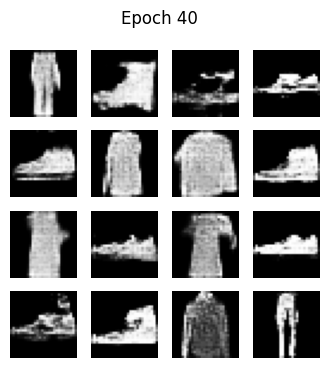

Epoch 41/50 | G Loss: 1.2024 | D Loss: 1.0741
Epoch 42/50 | G Loss: 1.1911 | D Loss: 1.0846
Epoch 43/50 | G Loss: 1.2253 | D Loss: 1.0605
Epoch 44/50 | G Loss: 1.1719 | D Loss: 1.0939
Epoch 45/50 | G Loss: 1.2100 | D Loss: 1.0591
Epoch 46/50 | G Loss: 1.1742 | D Loss: 1.0920
Epoch 47/50 | G Loss: 1.1361 | D Loss: 1.1216
Epoch 48/50 | G Loss: 1.1139 | D Loss: 1.1217
Epoch 49/50 | G Loss: 1.1746 | D Loss: 1.0876
Epoch 50/50 | G Loss: 1.2021 | D Loss: 1.0617


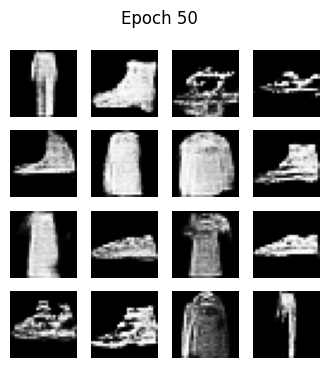

In [11]:
g_losses = []
d_losses = []


@tf.function
def train_step(images):
    noise = tf.random.normal([BATCH_SIZE, noise_dim])
    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        generated = generator(noise, training=True)
        real_output = discriminator(images, training=True)
        fake_output = discriminator(generated, training=True)
        g_loss = generator_loss(fake_output)
        d_loss = discriminator_loss(real_output, fake_output)

    gradients_gen = gen_tape.gradient(g_loss, generator.trainable_variables)
    gradients_disc = disc_tape.gradient(d_loss, discriminator.trainable_variables)

    g_optimizer.apply_gradients(zip(gradients_gen, generator.trainable_variables))
    d_optimizer.apply_gradients(zip(gradients_disc, discriminator.trainable_variables))

    return g_loss, d_loss

def train(dataset, epochs):
    for epoch in range(epochs):
        g_loss_epoch = []
        d_loss_epoch = []

        for image_batch in dataset:
            g_loss, d_loss = train_step(image_batch)
            g_loss_epoch.append(g_loss)
            d_loss_epoch.append(d_loss)

        g_losses.append(np.mean(g_loss_epoch))
        d_losses.append(np.mean(d_loss_epoch))

        print(f"Epoch {epoch+1}/{epochs} | G Loss: {g_losses[-1]:.4f} | D Loss: {d_losses[-1]:.4f}")

        if (epoch + 1) % 10 == 0 or epoch == 0:
            generate_images(generator, epoch+1, seed)

# Iniciar entrenamiento con la base de datos de ropa
train(dataset_fashion, EPOCHS)

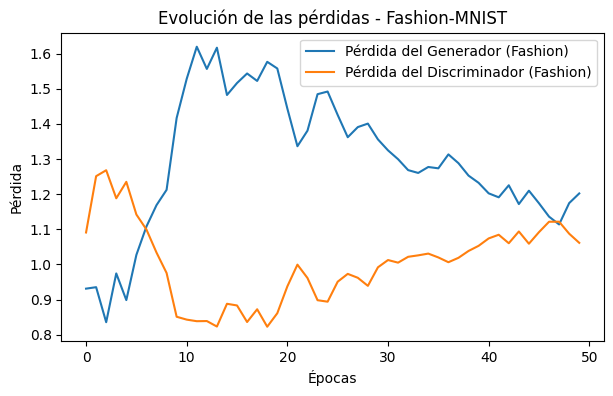

In [12]:
# Mostrar curva de pérdidas al final para Fashion-MNIST
plt.figure(figsize=(7, 4))
plt.plot(g_losses, label="Pérdida del Generador (Fashion)")
plt.plot(d_losses, label="Pérdida del Discriminador (Fashion)")
plt.xlabel("Épocas")
plt.ylabel("Pérdida")
plt.title("Evolución de las pérdidas - Fashion-MNIST")
plt.legend()
plt.show()